# Graph Neural Networks for Crystals
*AI School 26 · Aachen*


In [20]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import workshop as wk

np.random.seed(0)
torch.manual_seed(0)

data = wk.load_data()        

print(data.formulas[0], "| measured theta =", data.theta[0], "K")
print(data.structures[0])

6000 crystals read in 8 s
LaTbTmLuAs4 | measured theta = 117.71 K
Full Formula (La1 Tb1 Tm1 Lu1 As4)
Reduced Formula: LaTbTmLuAs4
abc   :   7.210002   4.175943   7.233809
angles:  90.000000 109.521128  90.000000
pbc   :       True       True       True
Sites (8)
  #  SP           a    b         c
---  ----  --------  ---  --------
  0  La    0         0    0
  1  Tb    0         0.5  0.5
  2  Tm    0.5       0.5  0
  3  Lu    0.5       0    0.5
  4  As    0.262716  0.5  0.263667
  5  As    0.737284  0.5  0.736333
  6  As    0.744088  0    0.257247
  7  As    0.255912  0    0.742753


---
# Part 1 · MLP
## 1a. In NumPy

In [21]:
x = np.array([0.8, -1.2, 0.4, 1.5])          # inputs
W = np.random.default_rng(0).normal(size=(5, 4))   # weights
b = np.random.default_rng(1).normal(size=5)        # bias 

def relu(z):
    return np.maximum(z, 0)

def neuron(x, W, b):
    return relu(W @ x + b)

h_np = neuron(x, W, b)
print("numpy:", h_np.round(3))

numpy: [1.018 1.901 1.099 0.    2.578]


## 1b. In PyTorch

In [22]:
layer = nn.Linear(4, 5).double()              #nn.Linear(4, 5) is the W @ x + b above, with the weights stored inside it.
with torch.no_grad():                         # put our W and b into the layer as torch tensors
    layer.weight.copy_(torch.tensor(W))
    layer.bias.copy_(torch.tensor(b))

xt = torch.tensor(x)  # We need to convert x into a torch tensor

h_torch = torch.relu(layer(xt))

print("numpy:", h_np.round(3))
print("torch:", h_torch.detach().numpy().round(3))
print("same :", np.allclose(h_np, h_torch.detach().numpy()))

numpy: [1.018 1.901 1.099 0.    2.578]
torch: [1.018 1.901 1.099 0.    2.578]
same : True


## 1c. A MLP

In [23]:
rng = np.random.default_rng(0)
SIZES = [4, 5, 4, 3]
PARAMS = [(rng.normal(size=(o, i)), rng.normal(size=o)) for i, o in zip(SIZES[:-1], SIZES[1:])]

def mlp(v):
    for W_, b_ in PARAMS[:-1]:
        v = neuron(v, W_, b_)
    W_, b_ = PARAMS[-1]
    return (W_ @ v + b_).mean()        # last layer linear, then pool the 3 outputs into 1

print("prediction:            ", round(mlp(x), 4))
print("same inputs, new order:", round(mlp(x[[2, 0, 3, 1]]), 4))

prediction:             -2.8117
same inputs, new order: -0.5735


## 1d. Example of torch MLP

In [24]:
def mlp_torch(v):
    layers = []
    for k, (i, o) in enumerate(zip(SIZES[:-1], SIZES[1:])):
        layer = nn.Linear(i, o).double()
        W_, b_ = PARAMS[k]         

        with torch.no_grad():
            layer.weight.copy_(torch.tensor(W_))
            layer.bias.copy_(torch.tensor(b_))

        layers.append(layer)

        if k < len(SIZES) - 2:  
            layers.append(nn.ReLU())
            
    return nn.Sequential(*layers)(torch.tensor(v))

---
# Part 2 · Crystal graphs


## 2a. Atomic representations

In [25]:
from pymatgen.core import Element

def features(struct):
    rows = []
    for site in struct:
        el = Element(site.specie.symbol)
        chi = el.X if np.isfinite(el.X) else 0.0
        rows.append([el.Z / 100, chi / 4, el.row / 7, el.group / 18])
    return np.array(rows)              # 4 numbers per atom

print(data.formulas[0])
print(features(data.structures[0]).round(2))

LaTbTmLuAs4
[[0.57 0.28 0.86 0.17]
 [0.65 0.28 0.86 0.17]
 [0.69 0.31 0.86 0.17]
 [0.71 0.32 0.86 0.17]
 [0.33 0.55 0.57 0.83]
 [0.33 0.55 0.57 0.83]
 [0.33 0.55 0.57 0.83]
 [0.33 0.55 0.57 0.83]]


## 2b. Creating the graph
`struct.get_neighbor_list(r)` gives every pair closer than `r`, periodic copies included, as four arrays:
centre atom, neighbour, which copy of the cell the neighbour sits in, and the distance. Use
`wk.keep_nearest(...)` to trim that to the k nearest neighbours of each atom.

In [26]:
def graph(struct):
    centre, neighbour, image, distance = struct.get_neighbor_list(r=5.0)
    centre, neighbour, image, distance = wk.keep_nearest(centre, neighbour, image, distance, k=12)
    return centre, neighbour, distance

c, n, d = graph(data.structures[0])
print(graph(data.structures[0]))
print(len(data.structures[0]), "atoms ->", len(c), "edges")
print("shortest bond", d.min().round(2), "A   longest kept", d.max().round(2), "A")

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7], dtype=int64), array([6, 7, 4, 5, 5, 4, 2, 2, 2, 2, 3, 3, 4, 5, 6, 6, 7, 7, 3, 3, 3, 3,
       2, 2, 6, 6, 7, 7, 4, 5, 0, 0, 0, 0, 1, 1, 7, 6, 4, 5, 5, 4, 1, 1,
       1, 1, 0, 0, 3, 3, 1, 2, 0, 0, 5, 7, 7, 6, 6, 4, 3, 3, 1, 2, 0, 0,
       4, 6, 6, 7, 7, 5, 3, 1, 1, 2, 2, 0, 5, 5, 4, 4, 7, 6, 3, 1, 1, 2,
       2, 0, 4, 4, 5, 5, 6, 7], dtype=int64), array([3.02688398, 3.02688398, 3.02835464, 3.02835464, 3.02835464,
       3.02835464, 4.1660123 , 4.1660123 , 4.1660123 , 4.1660123 ,
       4.16701195, 4.16701195, 2.94529999, 2.94529999, 2.94658809,
       2.94658809, 2.94658809, 2.94658809, 4.1660123 , 4.1660123 ,
       4.1660123 , 4.1660123 , 4.16701195, 4.16701195, 

---
# Part 3 · Message passing, twice

Lets use the MLP from the first step as the function that modulates the message:

$$h_i \;\leftarrow\; h_i + \sum_{j \in \text{neighbours}(i)} MLP(h_i|d_{ij}|h_j)$$

(a|b) referes to the concatenation of the vectors, use np.concatenate((a,b), axis=1)

## 3a. In NumPy

In [27]:
def MLP_message():
    sizes = [2 * 4 + 1, 16, 4]         # (h_i | h_j | d) -> hidden -> as wide as h again
    r = np.random.default_rng(1)
    return [(r.normal(size=(o, i)) * 0.3, r.normal(size=o) * 0.3)
            for i, o in zip(sizes[:-1], sizes[1:])]

MSG = MLP_message()      # build it once here, so 3b can reuse exactly these weights

def message_np(h, c, n, d):
    v = np.concatenate([h[c], h[n], d[:, None]], axis=1)
    for W_, b_ in MSG[:-1]:
        v = np.maximum(v @ W_.T + b_, 0)      # v @ W.T does every edge at once
    W_, b_ = MSG[-1]
    msg = v @ W_.T + b_                       # (E, 4): one message per edge

    agg = np.zeros_like(h)                    # (N, 4): one slot per atom
    np.add.at(agg, c, msg)
    return h + agg

def pool_np(h):
    return h.mean(axis=0)

h = features(data.structures[0])
for _ in range(3):
    h = message_np(h, c, n, d)
print("crystal vector:", pool_np(h).round(3))
print("prediction with random weights:", round(mlp(pool_np(h)), 4))

crystal vector: [-116.422  115.41    88.932  -39.82 ]
prediction with random weights: -51.1047


## 3b. The same two steps in PyTorch

* `torch.zeros_like(h).index_add_(0, c, msg)` is the torch version of `np.add.at`;

In [28]:
def MLP_message_torch():
    layers = []
    for k, (W_, b_) in enumerate(MSG):
        lin = nn.Linear(W_.shape[1], W_.shape[0])
        with torch.no_grad():
            lin.weight.copy_(torch.tensor(W_, dtype=torch.float32))
            lin.bias.copy_(torch.tensor(b_, dtype=torch.float32))
        layers.append(lin)
        if k < len(MSG) - 1:
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)

MSG_TORCH = MLP_message_torch()

def message_torch(h, c, n, d):
    msg = MSG_TORCH(torch.cat([h[c], h[n], d[:, None]], dim=1))
    return h + torch.zeros_like(h).index_add_(0, c, msg)

def pool_torch(h):
    return h.mean(dim=0)

ht = torch.tensor(features(data.structures[0]), dtype=torch.float32)
ct, nt, dt = torch.tensor(c), torch.tensor(n), torch.tensor(d, dtype=torch.float32)
for _ in range(3):
    ht = message_torch(ht, ct, nt, dt)
pooled = pool_torch(ht)

print("numpy:", pool_np(h).round(3))
print("torch:", pooled.detach().numpy().round(3))

numpy: [-116.422  115.41    88.932  -39.82 ]
torch: [-116.422  115.41    88.932  -39.82 ]


---
# Part 4 · Build the GNN and train it

### The target
Theta is an invented property, but it follows a fixed formula:

$$\omega = 800\,\mathrm{K}\sqrt{\tfrac{20\,\mathrm{u}}{\langle m\rangle}}\,\tfrac{2.5\,\text{A}}{\langle d\rangle}
\qquad \lambda = 0.25 + 0.9\,\langle|\chi_i-\chi_j|\rangle \qquad \Theta = \omega\,e^{-1/\lambda}$$


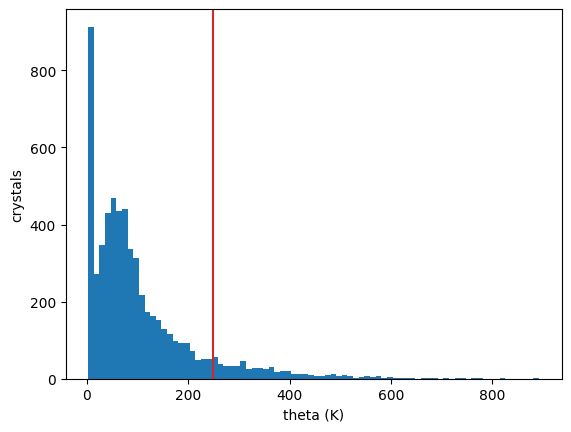

above 250 K: 585 of 6000
train 4800   validation 600   test 600


In [29]:
from sklearn.model_selection import train_test_split

plt.hist(data.theta, bins=80)
plt.axvline(250, color="C3")
plt.xlabel("theta (K)")
plt.ylabel("crystals")
plt.show()
print(f"above 250 K: {(data.theta > 250).sum()} of {len(data.theta)}")

def split(theta, seed=0):
    idx = np.arange(len(theta))
    i_tr, i_rest = train_test_split(idx, test_size=0.2, random_state=seed)   # 80 % train
    i_va, i_te = train_test_split(i_rest, test_size=0.5, random_state=seed)  # 10 % / 10 %
    print(f"train {len(i_tr)}   validation {len(i_va)}   test {len(i_te)}")
    return i_tr, i_va, i_te
i_tr, i_va, i_te = split(data.theta)

### Turn every crystal into tensors

In [30]:
graphs = []
for st_ in data.structures:
    c_, n_, d_ = graph(st_)
    graphs.append((torch.tensor(features(st_), dtype=torch.float32),
                   torch.tensor(c_), torch.tensor(n_), torch.tensor(d_, dtype=torch.float32)))
print(len(graphs), "graphs ready")

6000 graphs ready


### 4a. The model

In [31]:
def pool_batch(h, b, n_graphs):
    # several crystals are stacked now, so the plain mean of pool_torch is not enough:
    # b says which crystal each atom belongs to, so average the atoms of each one separately
    total = torch.zeros(n_graphs, h.shape[1]).index_add_(0, b, h)   # sum the atoms of each crystal
    count = torch.bincount(b, minlength=n_graphs)[:, None]    # atoms per crystal
    return total / count


class MyGNN(nn.Module):
    def __init__(self, dim=64, layers=3, out=1):
        super().__init__()
        self.embed = nn.Linear(4, dim)                        # 4 atom features -> dim numbers
        self.phi = nn.ModuleList([
            nn.Sequential(nn.Linear(2 * dim + 1, dim), nn.SiLU(), nn.Linear(dim, dim))
            for _ in range(layers)])                          # one message network per layer
        self.head = nn.Sequential(nn.Linear(dim, dim), nn.SiLU(), nn.Linear(dim, out))

    def forward(self, x, c, n, d, b, n_graphs):
        h = self.embed(x)
        for phi in self.phi:
            msg = phi(torch.cat([h[c], h[n], d[:, None]], dim=1))
            h = h + torch.zeros_like(h).index_add_(0, c, msg) / 12
        pooled = pool_batch(h, b, n_graphs)
        return self.head(pooled)

model = MyGNN()
print(sum(p.numel() for p in model.parameters()), "weights to learn")

41985 weights to learn


### 4b. The loss

epoch   0   train 68.702   validation 64.698
epoch   1   train 37.910   validation 37.760
epoch   2   train 38.076   validation 37.036
epoch   3   train 35.840   validation 35.419
epoch   4   train 34.006   validation 33.717
epoch   5   train 31.220   validation 30.889
epoch   6   train 25.190   validation 24.749
epoch   7   train 23.816   validation 23.624
epoch   8   train 23.011   validation 22.272
epoch   9   train 21.568   validation 20.779
epoch  10   train 20.574   validation 19.731
epoch  11   train 20.126   validation 18.803
epoch  12   train 21.838   validation 20.527
epoch  13   train 18.756   validation 17.576
epoch  14   train 20.713   validation 18.441
epoch  15   train 19.578   validation 18.325
epoch  16   train 18.005   validation 16.641
epoch  17   train 16.753   validation 15.026
epoch  18   train 16.468   validation 15.073
epoch  19   train 16.369   validation 15.076
done in 19 s


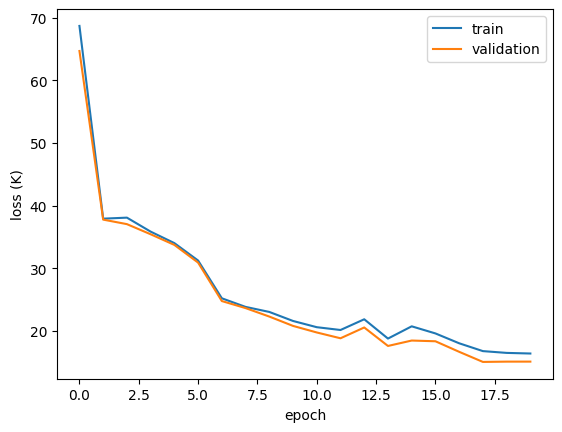

In [32]:
def loss(pred, target):
    return (pred - target).abs().mean()

history = wk.train(model, loss, graphs, data.theta, i_tr, i_va, epochs=20, lr=1e-3)
plt.plot(history[:, 0], label="train")        # history: one row per epoch,
plt.plot(history[:, 1], label="validation")   # column 0 train, column 1 validation
plt.xlabel("epoch")
plt.ylabel("loss (K)")
plt.legend()
plt.show()

### 4c. Is it any good?

your GNN            MAE  15.1 K
predict the median  MAE  73.2 K


/tmp/ipykernel_3725160/2192974504.py:12: RuntimeWarning: Mean of empty slice.
  mae = [np.abs(pred - y_va)[which == j].mean() for j in range(len(edges) - 1)]
/home/users/ruivopy6/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


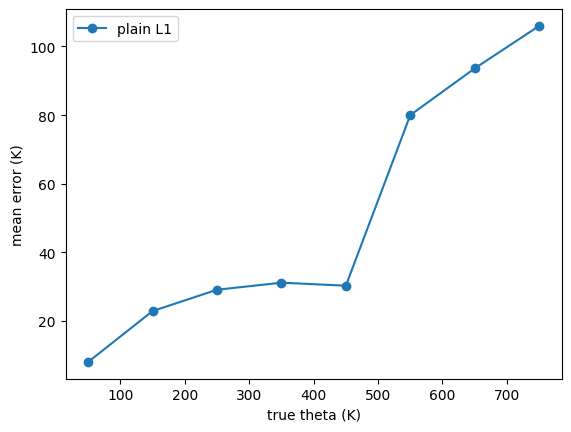

In [33]:
pred_va = wk.predict(model, graphs, i_va)

y_va = data.theta[i_va]
guess = np.median(data.theta[i_tr])            # the dumbest model: always the same number

print(f"your GNN            MAE {np.abs(pred_va - y_va).mean():5.1f} K")
print(f"predict the median  MAE {np.abs(guess - y_va).mean():5.1f} K")

def error_vs_theta(pred, label):               # mean error in slices of 100 K
    edges = np.arange(0, 901, 100)
    which = np.digitize(y_va, edges) - 1
    mae = [np.abs(pred - y_va)[which == j].mean() for j in range(len(edges) - 1)]
    plt.plot(edges[:-1] + 50, mae, "o-", label=label)

error_vs_theta(pred_va, "plain L1")
plt.xlabel("true theta (K)")
plt.ylabel("mean error (K)")
plt.legend()
plt.show()

### 4d. Play
Change one thing, retrain, and watch the curves:

* `epochs=40` — does the validation loss keep falling?
* `lr=1e-2`, then `lr=1e-4` — too big jumps around, too small barely moves
* `MyGNN(layers=1)` or `MyGNN(layers=5)` — how far does an atom need to see?
* `MyGNN(dim=16)` — a smaller model; how much does it lose?

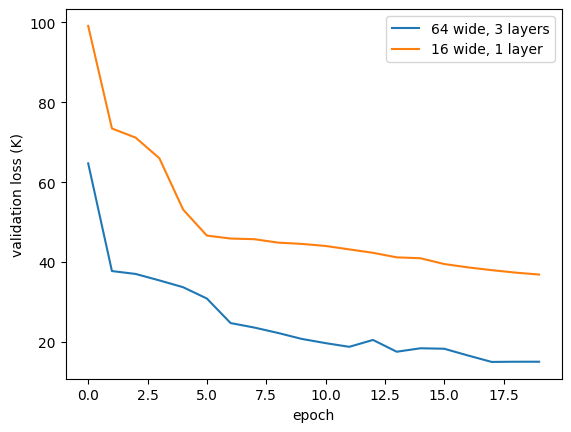

In [34]:
model_small = MyGNN(dim=16, layers=1)
hist_small = wk.train(model_small, loss, graphs, data.theta, i_tr, i_va, epochs=20, quiet=True)

plt.plot(history[:, 1], label="64 wide, 3 layers")
plt.plot(hist_small[:, 1], label="16 wide, 1 layer")
plt.xlabel("epoch")
plt.ylabel("validation loss (K)")
plt.legend()
plt.show()

---
# Part 5 · Playing with GNNs


### 5a. A loss for high Theta

/tmp/ipykernel_3725160/2192974504.py:12: RuntimeWarning: Mean of empty slice.
  mae = [np.abs(pred - y_va)[which == j].mean() for j in range(len(edges) - 1)]


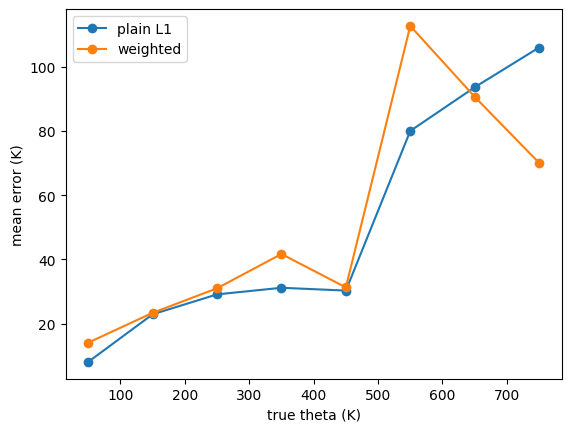

In [35]:
def weighted_loss(pred, target, beta=8.0, theta0=250):   # theta0 in K, the threshold we care about
    w = 1 + beta * target / theta0                 # a 250 K crystal counts 9x a 0 K one
    return (w * (pred - target).abs()).mean() / w.mean()

model_b = MyGNN()
hist_b = wk.train(model_b, weighted_loss, graphs, data.theta, i_tr, i_va, epochs=20, quiet=True)
pred_b = wk.predict(model_b, graphs, i_va)

error_vs_theta(pred_va, "plain L1")
error_vs_theta(pred_b, "weighted")
plt.xlabel("true theta (K)")
plt.ylabel("mean error (K)")
plt.legend()
plt.show()

### 5b. Physical informed GNNs

/tmp/ipykernel_3725160/2192974504.py:12: RuntimeWarning: Mean of empty slice.
  mae = [np.abs(pred - y_va)[which == j].mean() for j in range(len(edges) - 1)]


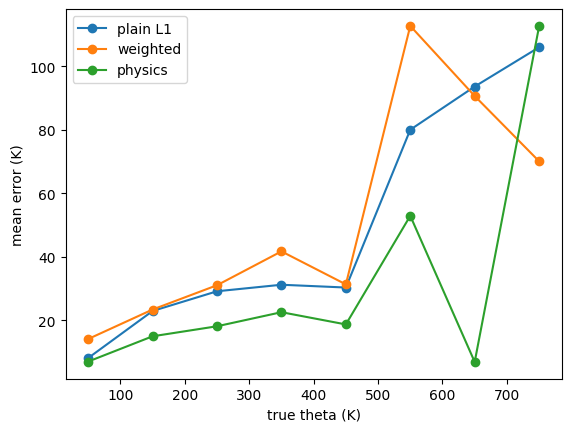

In [36]:
import torch.nn.functional as F

def compute_theta (lam, omega):
    return omega * torch.exp(-1 / lam)

def unpack(out):                            # the model's two raw numbers -> lambda and omega
    lam = 0.25 + F.softplus(out[:, 0])      # softplus keeps lambda above 0.25 and keeps a gradient
    omega = 300.0 * torch.exp(out[:, 1])    # the head predicts LOG omega, around 300 K
    return lam, omega

def physics_loss(out, target):
    lam, omega = unpack(out)
    return (compute_theta(lam, omega) - target).abs().mean()

model_c = MyGNN(out=2)                      # two numbers per crystal: lambda and log omega
hist_c = wk.train(model_c, physics_loss, graphs, data.theta, i_tr, i_va, epochs=20, quiet=True)

raw = torch.tensor(wk.predict(model_c, graphs, i_va))
lam_hat, om_hat = unpack(raw)               # the same transformation as in the loss
pred_c = compute_theta(lam_hat, om_hat).numpy()

error_vs_theta(pred_va, "plain L1")
error_vs_theta(pred_b, "weighted")
error_vs_theta(pred_c, "physics")
plt.xlabel("true theta (K)")
plt.ylabel("mean error (K)")
plt.legend()
plt.show()

#Note that the model will initialy predict random values of lambda
#A lambda close to 0 makes exp(-1/lambda) explode, so keep it away from 0 with
#0.25 + F.softplus(...) 
# #Omega spans 155..11881 K, too wide to predict directly: predict its log

### 5c. Parity

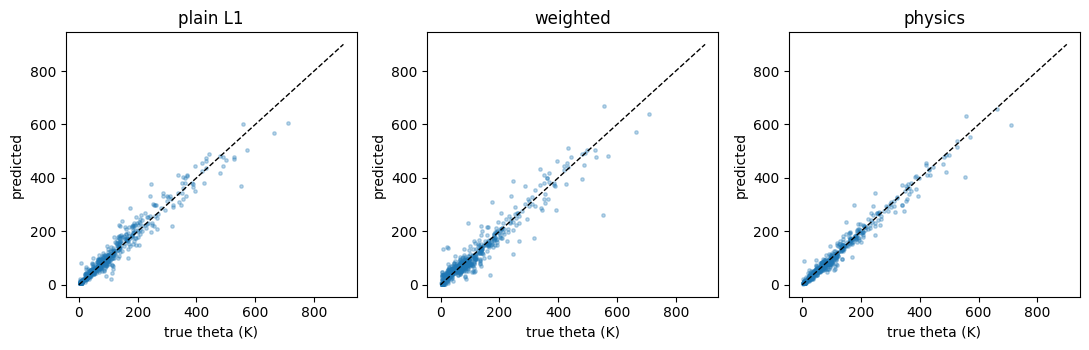

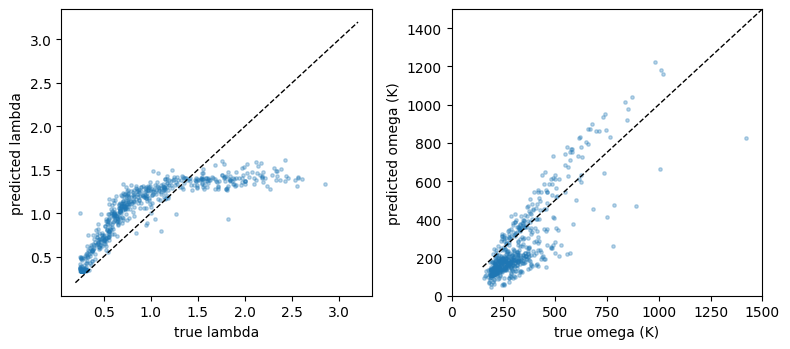

model          MAE   MAE above 250 K
plain L1     15.1 K            37.6 K
weighted     19.8 K            44.4 K
physics      10.9 K            23.2 K


In [37]:
preds = {"plain L1": pred_va, "weighted": pred_b, "physics": pred_c}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, (name, p) in zip(ax, preds.items()):
    a.scatter(y_va, p, s=6, alpha=0.3)
    a.plot([0, 900], [0, 900], "k--", lw=1)
    a.set_xlabel("true theta (K)")
    a.set_ylabel("predicted")
    a.set_title(name)
plt.tight_layout()
plt.show()

# the physics model predicts the two ingredients, so we can check those too
fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
ax[0].scatter(data.lam[i_va], lam_hat.numpy(), s=6, alpha=0.3)
ax[0].plot([0.2, 3.2], [0.2, 3.2], "k--", lw=1)
ax[0].set_xlabel("true lambda"); ax[0].set_ylabel("predicted lambda")
ax[1].scatter(data.omega[i_va], om_hat.numpy(), s=6, alpha=0.3)
ax[1].plot([150, 1500], [150, 1500], "k--", lw=1)
ax[1].set_xlim(0, 1500)
ax[1].set_ylim(0, 1500)
ax[1].set_xlabel("true omega (K)"); ax[1].set_ylabel("predicted omega (K)")
plt.tight_layout()
plt.show()

high = y_va > 250
print(f"{'model':<10} {'MAE':>7} {'MAE above 250 K':>17}")
for name, p in preds.items():
    err = np.abs(p - y_va)
    print(f"{name:<10} {err.mean():6.1f} K {err[high].mean():15.1f} K")

### 5e. Classification

TP 56   FP 5   FN 3   TN 536
precision 0.92   recall 0.95


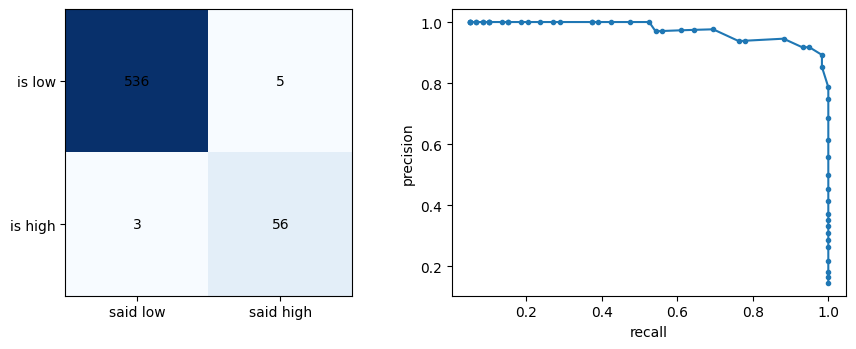

In [38]:
THRESHOLD = 250        # K - try other values

p = preds["physics"]
flag = p > THRESHOLD          # what the model says
real = y_va > THRESHOLD       # what is true

TP = int((flag & real).sum())     # said high, is high
FP = int((flag & ~real).sum())    # said high, is low
FN = int((~flag & real).sum())    # said low,  is high
TN = int((~flag & ~real).sum())   # said low,  is low
print(f"TP {TP}   FP {FP}   FN {FN}   TN {TN}")
print(f"precision {TP / max(TP + FP, 1):.2f}   recall {TP / max(TP + FN, 1):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].imshow([[TN, FP], [FN, TP]], cmap="Blues")
for i, row in enumerate([[TN, FP], [FN, TP]]):
    for j, v in enumerate(row):
        ax[0].text(j, i, v, ha="center", va="center")
ax[0].set_xticks([0, 1], ["said low", "said high"])
ax[0].set_yticks([0, 1], ["is low", "is high"])

prec, rec = [], []
for t in np.arange(50, 600, 10):        # slide the threshold and watch the two move
    f = p > t
    prec.append((f & real).sum() / max(f.sum(), 1))
    rec.append((f & real).sum() / max(real.sum(), 1))
ax[1].plot(rec, prec, "o-", ms=3)
ax[1].set_xlabel("recall")
ax[1].set_ylabel("precision")
plt.tight_layout()
plt.show()